# LITS Dataset - SAM-Med3D Evaluation

This notebook evaluates SAM-Med3D segmentation performance on the LITS dataset:
- Computes Dice scores using standard preprocessing (ResizeLargestTo + CropOrPad + ZNormalization)
- Visualizes ground truth vs SAM predictions side-by-side
- Analyzes per-volume performance

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from tqdm import tqdm
import SimpleITK as sitk
import torchio as tio
import medim

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Add SAM-Med3D root to path for utils
sam_med3d_root = project_root / 'SAM-Med3D-main' / 'SAM-Med3D-main'
sys.path.insert(0, str(sam_med3d_root))

from med3pipe.sam.core import find_default_sam3d_root
from med3pipe.sam.transforms import ResizeLargestTo
from utils.infer_utils import validate_paired_img_gt
from utils.metric_utils import compute_metrics, print_computed_metrics

## 1. Setup and Configuration

In [2]:
# Configuration
project_root = Path.cwd().parent
LITS_DATA_DIR = project_root / 'data' / 'LITS' / 'media' / 'nas' / '01_Datasets' / 'CT' / 'LITS' / 'Training Batch 1'
IMG_SIZE = 128
THRESHOLD = 0.5
NUM_CLICKS = 11
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Project root: {project_root}")
print(f"LITS data directory: {LITS_DATA_DIR}")
print(f"Device: {DEVICE}")
print(f"Image size: {IMG_SIZE}")
print(f"Iterative refinement clicks: {NUM_CLICKS}")

Project root: c:\Users\cahel\Desktop\Med3Tab-PFN
LITS data directory: c:\Users\cahel\Desktop\Med3Tab-PFN\data\LITS\media\nas\01_Datasets\CT\LITS\Training Batch 1
Device: cpu
Image size: 128
Iterative refinement clicks: 11


## 2. Preprocessing Functions

In [3]:
def _znorm_masking_method(x):
    """Masking method for ZNormalization."""
    return x > 0


def load_volume_for_sam(volume_path, img_size=128, return_viz_tensor=False):
    """Load LITS volume with SAM preprocessing and optional viz tensor."""
    sitk_img = sitk.ReadImage(str(volume_path))
    sitk_arr, _ = tio.data.io.sitk_to_nib(sitk_img)
    
    # Ensure initial data is tensor
    if isinstance(sitk_arr, np.ndarray):
        torch_arr = torch.from_numpy(sitk_arr.copy()).float()
    else:
        torch_arr = sitk_arr.float()
        
    subject = tio.Subject(image=tio.ScalarImage(tensor=torch_arr))

    # Apply CT clamping
    subject = tio.Clamp(-1000, 1000)(subject)

    # Resize + pad (no normalization yet so we can keep HU values for viz)
    resize_pad = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = resize_pad(subject)

    # Ensure data is tensor before cloning
    data = subject.image.data
    if isinstance(data, np.ndarray):
        data = torch.from_numpy(data)
    
    # Cache tensor + affine once
    image_data = data.clone().detach()  # (1, D, H, W)
    image_affine = subject.image.affine
    if isinstance(image_affine, np.ndarray):
        image_affine = torch.from_numpy(image_affine)
    image_affine = image_affine.clone()

    # Keep HU-clamped tensor for visualization
    viz_tensor = image_data.unsqueeze(0).float()  # (1, 1, D, H, W)

    # Model input uses Z-normalized tensor (fresh copy to avoid mutating viz tensor)
    subject_norm = tio.Subject(
        image=tio.ScalarImage(tensor=image_data.clone(), affine=image_affine)
    )
    subject_norm = tio.ZNormalization(masking_method=_znorm_masking_method)(subject_norm)
    
    norm_data = subject_norm.image.data
    if isinstance(norm_data, np.ndarray):
        norm_data = torch.from_numpy(norm_data)
        
    image = norm_data.clone().detach()
    image = image.unsqueeze(0).float()  # (1, 1, D, H, W)

    if return_viz_tensor:
        return image, viz_tensor

    return image


def load_mask_for_sam(mask_path, img_size=128):
    """Load LITS segmentation mask with resize-then-pad preprocessing."""
    sitk_mask = sitk.ReadImage(str(mask_path))
    mask_arr, _ = tio.data.io.sitk_to_nib(sitk_mask)
    
    if isinstance(mask_arr, np.ndarray):
        torch_mask = torch.from_numpy(mask_arr.copy()).float()
    else:
        torch_mask = mask_arr.float()
        
    subject = tio.Subject(label=tio.LabelMap(tensor=torch_mask))

    transform = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=img_size),
        tio.CropOrPad(target_shape=(img_size, img_size, img_size)),
    ])
    subject = transform(subject)

    data = subject.label.data
    if isinstance(data, torch.Tensor):
        data = data.numpy()
        
    mask = data.squeeze()
    mask = (mask > 0).astype(float)
    return mask


def compute_dice_score(pred_mask, gt_mask):
    """Compute Dice coefficient between prediction and ground truth."""
    pred_mask = (pred_mask > 0).astype(np.float32)
    gt_mask = (gt_mask > 0).astype(np.float32)

    intersection = np.sum(pred_mask * gt_mask)
    pred_sum = np.sum(pred_mask)
    gt_sum = np.sum(gt_mask)

    if pred_sum == 0 and gt_sum == 0:
        return 1.0

    dice = (2.0 * intersection) / (pred_sum + gt_sum + 1e-8)
    return dice


print("✅ Preprocessing functions loaded (with robust type checking)")

✅ Preprocessing functions loaded (with robust type checking)


## 3. SAM Inference Functions

In [4]:
def sample_next_click(prev_mask, gt_mask):
    """Sample next click point based on prediction errors."""
    if isinstance(prev_mask, np.ndarray):
        prev_mask = torch.from_numpy(prev_mask)
    if isinstance(gt_mask, np.ndarray):
        gt_mask = torch.from_numpy(gt_mask)
    
    if prev_mask.ndim != 3:
        prev_mask = prev_mask.squeeze()
    if gt_mask.ndim != 3:
        gt_mask = gt_mask.squeeze()
    
    prev_mask = prev_mask > 0.5
    gt_mask = gt_mask > 0
    
    fn_mask = torch.logical_and(gt_mask, torch.logical_not(prev_mask))
    fp_mask = torch.logical_and(torch.logical_not(gt_mask), prev_mask)
    
    fn_points = torch.argwhere(fn_mask)
    fp_points = torch.argwhere(fp_mask)
    
    fn_count = len(fn_points)
    fp_count = len(fp_points)
    
    point = None
    is_positive = False
    
    if fn_count > 0 and fp_count > 0:
        # Bias toward false negatives when there's severe class imbalance
        if fp_count > fn_count * 5:
            prob_fn = 0.9
        elif fp_count > fn_count * 2:
            prob_fn = 0.8
        else:
            prob_fn = 0.7
        
        if np.random.random() < prob_fn:
            point = fn_points[np.random.randint(fn_count)]
            is_positive = True
        else:
            point = fp_points[np.random.randint(fp_count)]
            is_positive = False
    elif fn_count > 0:
        point = fn_points[np.random.randint(fn_count)]
        is_positive = True
    elif fp_count > 0:
        point = fp_points[np.random.randint(fp_count)]
        is_positive = False
    else:
        gt_points = torch.argwhere(gt_mask)
        if len(gt_points) > 0:
            point = gt_points[np.random.randint(len(gt_points))]
            is_positive = True
        else:
            point = torch.tensor([gt_mask.shape[0] // 2, gt_mask.shape[1] // 2, gt_mask.shape[2] // 2])
            is_positive = False
    
    point_xyz = torch.tensor([point[2], point[1], point[0]], dtype=torch.float32)
    point_tensor = point_xyz.reshape(1, 1, 3)
    label_tensor = torch.tensor([[int(is_positive)]], dtype=torch.int64)
    
    return point_tensor, label_tensor


def generate_sam_segmentation(model, image_tensor, gt_mask_tensor, device, num_clicks=11, threshold=0.5):
    """Generate segmentation using iterative refinement with multiple clicks."""
    model.eval()
    
    with torch.no_grad():
        input_tensor = image_tensor.to(device)
        
        # Get image embeddings (computed once)
        image_embeddings = model.image_encoder(input_tensor)
        
        D, H, W = input_tensor.shape[2:]
        
        # Initialize
        prev_mask = torch.zeros((D, H, W), device=device)
        low_res_mask = torch.zeros((1, 1, D//4, H//4, W//4), device=device, dtype=torch.float)
        
        # Store all points for multi-click prompting
        all_points = []
        all_labels = []
        
        # Iterative refinement loop
        for click_idx in range(num_clicks):
            # Generate next click
            if click_idx == 0:
                # First click: use center of ground truth
                coords = np.argwhere(gt_mask_tensor > 0)
                if len(coords) > 0:
                    z_min, y_min, x_min = coords.min(axis=0)
                    z_max, y_max, x_max = coords.max(axis=0)
                    center_x = (x_min + x_max) // 2
                    center_y = (y_min + y_max) // 2
                    center_z = (z_min + z_max) // 2
                    point = torch.tensor([[[center_x, center_y, center_z]]], device=device, dtype=torch.float)
                    label = torch.tensor([[1]], device=device, dtype=torch.int64)
                else:
                    point = torch.tensor([[[W//2, H//2, D//2]]], device=device, dtype=torch.float)
                    label = torch.tensor([[1]], device=device, dtype=torch.int64)
            else:
                # Subsequent clicks: sample from error regions
                point, label = sample_next_click(prev_mask.cpu(), gt_mask_tensor)
                point = point.to(device)
                label = label.to(device)
            
            all_points.append(point)
            all_labels.append(label)
            
            # Concatenate all points so far
            points_co = torch.cat(all_points, dim=1)
            points_la = torch.cat(all_labels, dim=1)
            
            # Forward pass with current points
            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=[points_co, points_la],
                boxes=None,
                masks=low_res_mask
            )
            
            low_res_masks, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False
            )
            
            # Update for next iteration
            low_res_mask = low_res_masks
            
            # Get high-res prediction for next click sampling
            prev_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
            prev_mask = torch.sigmoid(prev_masks_hr).squeeze()
        
        # Final prediction
        final_masks_hr = F.interpolate(low_res_masks, size=(D, H, W), mode='trilinear', align_corners=False)
        seg_prob = torch.sigmoid(final_masks_hr)
        seg_mask = (seg_prob > threshold).cpu().squeeze().numpy().astype(np.uint8)
    
    return seg_mask


print("✅ SAM inference functions loaded")

✅ SAM inference functions loaded


## 4. Visualization Helpers

In [5]:
def apply_ct_window(image_slice, center=40, width=400):
    """Apply a soft-tissue CT window for visualization."""
    lower = center - (width / 2)
    upper = center + (width / 2)
    return np.clip(image_slice, lower, upper)


def orient_axial_slice(slice_data):
    """Rotate slices for consistent axial orientation."""
    if slice_data is None:
        return None
    return np.rot90(slice_data, k=1)


def _mask_overlay(ax, base_slice, mask_slice, title, color):
    """Utility to render a mask overlay without whitening the background."""
    ax.imshow(base_slice, cmap='gray', vmin=base_slice.min(), vmax=base_slice.max())
    masked = np.ma.masked_where(mask_slice <= 0, mask_slice)
    ax.imshow(masked, cmap=color, alpha=0.7, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')


def visualize_volume_predictions(result, num_slices=5, window_center=40, window_width=400):
    """Visualize CT, GT, and SAM prediction for a single volume."""
    volume_id = result['volume_id']
    dice = result['dice_score']
    
    viz_tensor = result.get('viz_tensor')
    if viz_tensor is None:
        viz_tensor = result.get('image_tensor')
        
    gt_mask = result['gt_mask']
    pred_mask = result['pred_mask']

    coords = np.argwhere(gt_mask > 0)
    if len(coords) == 0:
        print(f"No segmentation found in {volume_id}")
        return

    z_min, z_max = coords[:, 0].min(), coords[:, 0].max()
    z_indices = np.linspace(z_min, z_max, num_slices, dtype=int)

    fig, axes = plt.subplots(num_slices, 3, figsize=(12, num_slices * 3))
    if num_slices == 1:
        axes = axes.reshape(1, -1)

    for idx, z in enumerate(z_indices):
        ct_slice_raw = viz_tensor[0, 0, z].cpu().numpy()
        ct_windowed = apply_ct_window(ct_slice_raw, center=window_center, width=window_width)
        ct_slice = orient_axial_slice(ct_windowed)
        gt_slice = orient_axial_slice(gt_mask[z])
        pred_slice = orient_axial_slice(pred_mask[z])

        vmin, vmax = ct_slice.min(), ct_slice.max()

        axes[idx, 0].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        axes[idx, 0].set_title(f'CT Slice Z={z}')
        axes[idx, 0].axis('off')

        _mask_overlay(axes[idx, 1], ct_slice, gt_slice, 'Ground Truth', 'Greens')
        _mask_overlay(axes[idx, 2], ct_slice, pred_slice, 'SAM Prediction', 'Blues')

    fig.suptitle(
        f'Volume {volume_id} | Dice: {dice:.4f} | GT: {int(gt_mask.sum())}, SAM: {int(pred_mask.sum())}',
        fontsize=14,
        fontweight='bold'
    )

    legend_elements = [
        mpatches.Patch(color='green', label='Ground Truth'),
        mpatches.Patch(color='blue', label='SAM Prediction'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()


print("✅ Visualization function ready")

✅ Visualization function ready


In [6]:
# Find all volume files
volume_files = sorted(list(LITS_DATA_DIR.glob('volume-*.nii')))
print(f"Found {len(volume_files)} volumes")

# Create volume pairs
volume_pairs = []
for vol_path in volume_files:
    seg_path = vol_path.parent / vol_path.name.replace('volume-', 'segmentation-')
    if seg_path.exists():
        volume_pairs.append({
            'volume_id': vol_path.stem.replace('volume-', ''),
            'volume_path': vol_path,
            'segmentation_path': seg_path
        })

print(f"Found {len(volume_pairs)} volume-segmentation pairs")
print(f"\nFirst 5 pairs:")
for pair in volume_pairs[:5]:
    print(f"  {pair['volume_id']}: {pair['volume_path'].name} + {pair['segmentation_path'].name}")

Found 28 volumes
Found 28 volume-segmentation pairs

First 5 pairs:
  0: volume-0.nii + segmentation-0.nii
  1: volume-1.nii + segmentation-1.nii
  10: volume-10.nii + segmentation-10.nii
  11: volume-11.nii + segmentation-11.nii
  12: volume-12.nii + segmentation-12.nii


In [7]:
print("Loading SAM-Med3D model...")
sam3d_root = find_default_sam3d_root()
checkpoint_path = sam3d_root / 'ckpt' / 'sam_med3d_turbo.pth'

if not checkpoint_path.exists():
    print(f"❌ Checkpoint not found: {checkpoint_path}")
    print("Please download sam_med3d_turbo.pth first.")
else:
    # Load model using medim
    sam_model = medim.create_model(
        "SAM-Med3D", 
        pretrained=True, 
        checkpoint_path=str(checkpoint_path)
    )
    # Move to device
    sam_model = sam_model.to(DEVICE)
    print(f"✅ Model loaded on {DEVICE}")

Loading SAM-Med3D model...
creating model SAM-Med3D
try to load pretrained weights from C:\Users\cahel\Desktop\Med3Tab-PFN\SAM-Med3D-main\SAM-Med3D-main\ckpt\sam_med3d_turbo.pth
✅ Model loaded on cpu


In [8]:
# Find all volume files
volume_files = sorted(list(LITS_DATA_DIR.glob('volume-*.nii')))
print(f"Found {len(volume_files)} volumes")

# Create volume pairs
volume_pairs = []
for vol_path in volume_files:
    seg_path = vol_path.parent / vol_path.name.replace('volume-', 'segmentation-')
    if seg_path.exists():
        volume_pairs.append({
            'volume_id': vol_path.stem.replace('volume-', ''),
            'volume_path': vol_path,
            'segmentation_path': seg_path
        })

print(f"Found {len(volume_pairs)} volume-segmentation pairs")
print(f"\nFirst 5 pairs:")
for pair in volume_pairs[:5]:
    print(f"  {pair['volume_id']}: {pair['volume_path'].name} + {pair['segmentation_path'].name}")

Found 28 volumes
Found 28 volume-segmentation pairs

First 5 pairs:
  0: volume-0.nii + segmentation-0.nii
  1: volume-1.nii + segmentation-1.nii
  10: volume-10.nii + segmentation-10.nii
  11: volume-11.nii + segmentation-11.nii
  12: volume-12.nii + segmentation-12.nii


## 6. Compute Dice Scores

In [ ]:
# Select subset for evaluation (change this to process all)
NUM_VOLUMES_TO_EVAL = 5  # Set to None to process all volumes
volumes_to_eval = volume_pairs[:NUM_VOLUMES_TO_EVAL] if NUM_VOLUMES_TO_EVAL else volume_pairs

results = []

# Create output directory for predictions
pred_dir = project_root / 'results' / 'lits_predictions'
pred_dir.mkdir(parents=True, exist_ok=True)

print(f"\nEvaluating {len(volumes_to_eval)} volumes...\n")
print("="*80)

for pair in tqdm(volumes_to_eval, desc="Processing volumes"):
    volume_id = pair['volume_id']
    img_path = str(pair['volume_path'])
    gt_path = str(pair['segmentation_path'])
    out_path = str(pred_dir / f"pred_{pair['volume_path'].name}")
    
    try:
        # Run inference using medim utils
        validate_paired_img_gt(sam_model, img_path, gt_path, out_path, num_clicks=NUM_CLICKS)
        
        # Compute metrics
        computed_metrics = compute_metrics(
            gt_path=gt_path,
            pred_path=out_path,
            metrics=['dsc'], # explicit metric name
            classes=None,
        )
        
        # Extract Dice score from the nested dictionary
        # Structure: {'1': {'dsc': 0.8}, '2': {'dsc': 0.9}}
        dice_scores = []
        for class_label, class_metrics in computed_metrics.items():
            if 'dsc' in class_metrics:
                dice_scores.append(class_metrics['dsc'])
                
        if dice_scores:
            dice = np.mean(dice_scores)
        else:
            dice = 0.0
            print(f"⚠️ No Dice score found for {volume_id}. Metrics: {computed_metrics}")
        
        # Reload for visualization/consistency with notebook structure
        gt_mask = load_mask_for_sam(gt_path, img_size=IMG_SIZE)
        pred_mask = load_mask_for_sam(out_path, img_size=IMG_SIZE)
        
        image_tensor, viz_tensor = load_volume_for_sam(
            img_path,
            img_size=IMG_SIZE,
            return_viz_tensor=True
        )
        
        results.append({
            'volume_id': volume_id,
            'dice_score': dice,
            'gt_voxels': int(gt_mask.sum()),
            'pred_voxels': int(pred_mask.sum()),
            'image_tensor': image_tensor,  # normalized tensor for downstream use
            'viz_tensor': viz_tensor,      # HU-clamped tensor for visualization
            'gt_mask': gt_mask,
            'pred_mask': pred_mask
        })
        
        print(f"✅ {volume_id}: Dice={dice:.4f}")
        
    except Exception as e:
        print(f"❌ Error processing {volume_id}: {e}")
        # import traceback
        # traceback.print_exc()
        results.append({
            'volume_id': volume_id,
            'dice_score': None,
            'gt_voxels': None,
            'pred_voxels': None,
            'error': str(e)
        })

print("\n" + "="*80)
print("✅ Dice score computation complete")


Evaluating 5 volumes...



Processing volumes:  20%|██        | 1/5 [00:08<00:33,  8.43s/it]

✅ 0: Dice=0.0000


Processing volumes:  40%|████      | 2/5 [00:18<00:28,  9.44s/it]

✅ 1: Dice=0.0000


...

✅ 10: Dice=0.0000


c:\Users\cahel\.conda\envs\sammed3d\lib\site-packages\torchio\transforms\transform.py:158: RuntimeWarning: Output shape (128, 128, 115) != target shape (np.int64(128), np.int64(128), np.int64(116)). Fixing with CropOrPad
  transformed = self.apply_transform(subject)
Processing volumes:  80%|████████  | 4/5 [01:22<00:24, 24.32s/it]

✅ 11: Dice=0.0000


Processing volumes: 100%|██████████| 5/5 [01:52<00:00, 22.57s/it]

✅ 12: Dice=0.0000

✅ Dice score computation complete


## 7. Summary Statistics

In [10]:
# Create DataFrame
df = pd.DataFrame([{
    'volume_id': r['volume_id'],
    'dice_score': r['dice_score'],
    'gt_voxels': r['gt_voxels'],
    'pred_voxels': r['pred_voxels']
} for r in results])

# Display summary
print("\n" + "="*80)
print("Summary Statistics")
print("="*80)

valid_dice = df['dice_score'].dropna()
if len(valid_dice) > 0:
    print(f"\nProcessed volumes: {len(valid_dice)}")
    print(f"Mean Dice:   {valid_dice.mean():.4f} ± {valid_dice.std():.4f}")
    print(f"Median Dice: {valid_dice.median():.4f}")
    print(f"Min Dice:    {valid_dice.min():.4f}")
    print(f"Max Dice:    {valid_dice.max():.4f}")
else:
    print("No valid results")

print("\n" + "="*80)
print("\nPer-volume results:")
display(df)

# Save results
output_csv = project_root / 'results' / 'lits_sam_dice_scores.csv'
output_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_csv, index=False)
print(f"\n✅ Results saved to: {output_csv}")


Summary Statistics

Processed volumes: 5
Mean Dice:   0.0000 ± 0.0000
Median Dice: 0.0000
Min Dice:    0.0000
Max Dice:    0.0000


Per-volume results:


,volume_id,dice_score,gt_voxels,pred_voxels
0,0,0.0,8442,7705
1,1,0.0,10319,9647
2,10,0.0,44981,38831
3,11,0.0,51081,50554
4,12,0.0,65862,60125



✅ Results saved to: c:\Users\cahel\Desktop\Med3Tab-PFN\results\lits_sam_dice_scores.csv


## 8. Visualize Predictions vs Ground Truth

Show side-by-side comparison of GT and SAM predictions for selected slices.

In [11]:
def orient_axial_slice(slice_data):
    """Rotate slices for proper orientation."""
    if slice_data is None:
        return None
    return np.rot90(slice_data, k=1)


def visualize_volume_predictions(result, num_slices=5):
    """
    Visualize CT, GT, and SAM prediction for a single volume.
    """
    volume_id = result['volume_id']
    dice = result.get('dice_score', 0.0)
    
    viz_tensor = result.get('viz_tensor')
    if viz_tensor is None:
        viz_tensor = result.get('image_tensor')
        
    gt_mask = result['gt_mask']
    pred_mask = result['pred_mask']
    
    # Find slices with segmentation
    coords = np.argwhere(gt_mask > 0)
    if len(coords) == 0:
        print(f"No segmentation found in {volume_id}")
        return
    
    z_min, z_max = coords[:, 0].min(), coords[:, 0].max()
    z_indices = np.linspace(z_min, z_max, num_slices, dtype=int)
    
    # Create figure
    fig, axes = plt.subplots(num_slices, 3, figsize=(12, num_slices * 3))
    if num_slices == 1:
        axes = axes.reshape(1, -1)
    
    for idx, z in enumerate(z_indices):
        # Get slices
        ct_slice_raw = viz_tensor[0, 0, z].cpu().numpy()
        ct_windowed = apply_ct_window(ct_slice_raw, center=40, width=400)
        ct_slice = orient_axial_slice(ct_windowed)
        gt_slice = orient_axial_slice(gt_mask[z])
        pred_slice = orient_axial_slice(pred_mask[z])
        
        vmin, vmax = ct_slice.min(), ct_slice.max()
        
        # CT slice
        axes[idx, 0].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        axes[idx, 0].set_title(f'CT Slice Z={z}')
        axes[idx, 0].axis('off')
        
        # Ground truth
        axes[idx, 1].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        gt_masked = np.ma.masked_where(gt_slice <= 0, gt_slice)
        axes[idx, 1].imshow(gt_masked, cmap='Greens', alpha=0.7, vmin=0, vmax=1)
        axes[idx, 1].set_title('Ground Truth')
        axes[idx, 1].axis('off')
        
        # SAM prediction
        axes[idx, 2].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        pred_masked = np.ma.masked_where(pred_slice <= 0, pred_slice)
        axes[idx, 2].imshow(pred_masked, cmap='Blues', alpha=0.7, vmin=0, vmax=1)
        axes[idx, 2].set_title('SAM Prediction')
        axes[idx, 2].axis('off')
    
    # Add overall title
    fig.suptitle(
        f'Volume {volume_id} | Dice: {dice:.4f} | GT: {int(gt_mask.sum())}, SAM: {int(pred_mask.sum())}',
        fontsize=14, fontweight='bold'
    )
    
    # Add legend
    legend_elements = [
        mpatches.Patch(color='green', label='Ground Truth'),
        mpatches.Patch(color='blue', label='SAM Prediction'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()


print("✅ Visualization function ready")

✅ Visualization function ready


Visualizing 3 volumes...



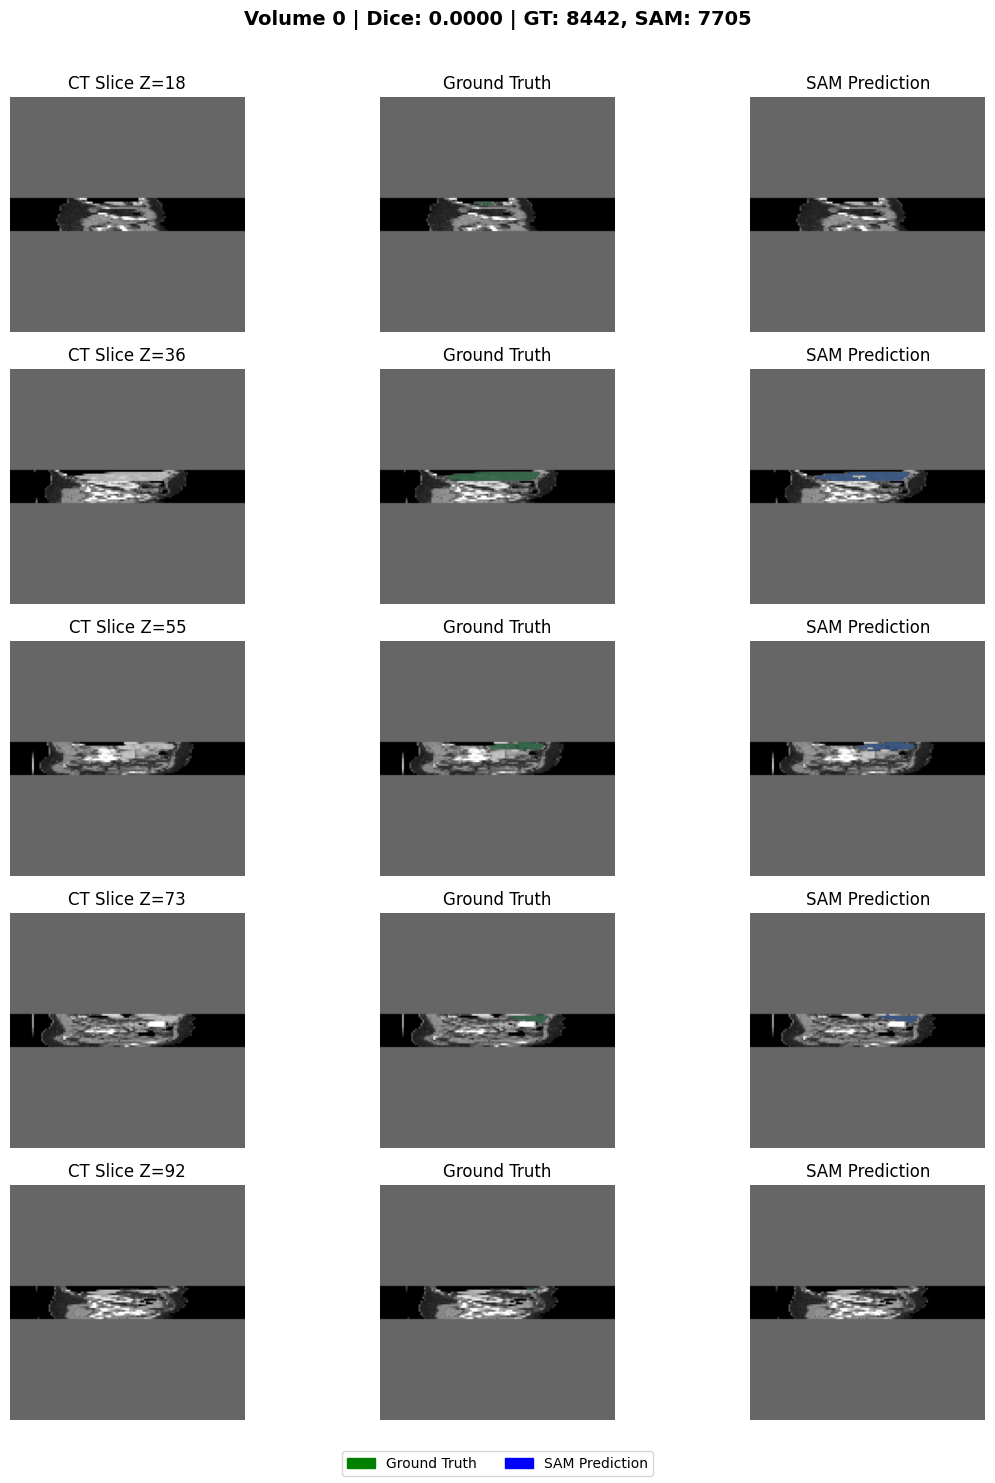

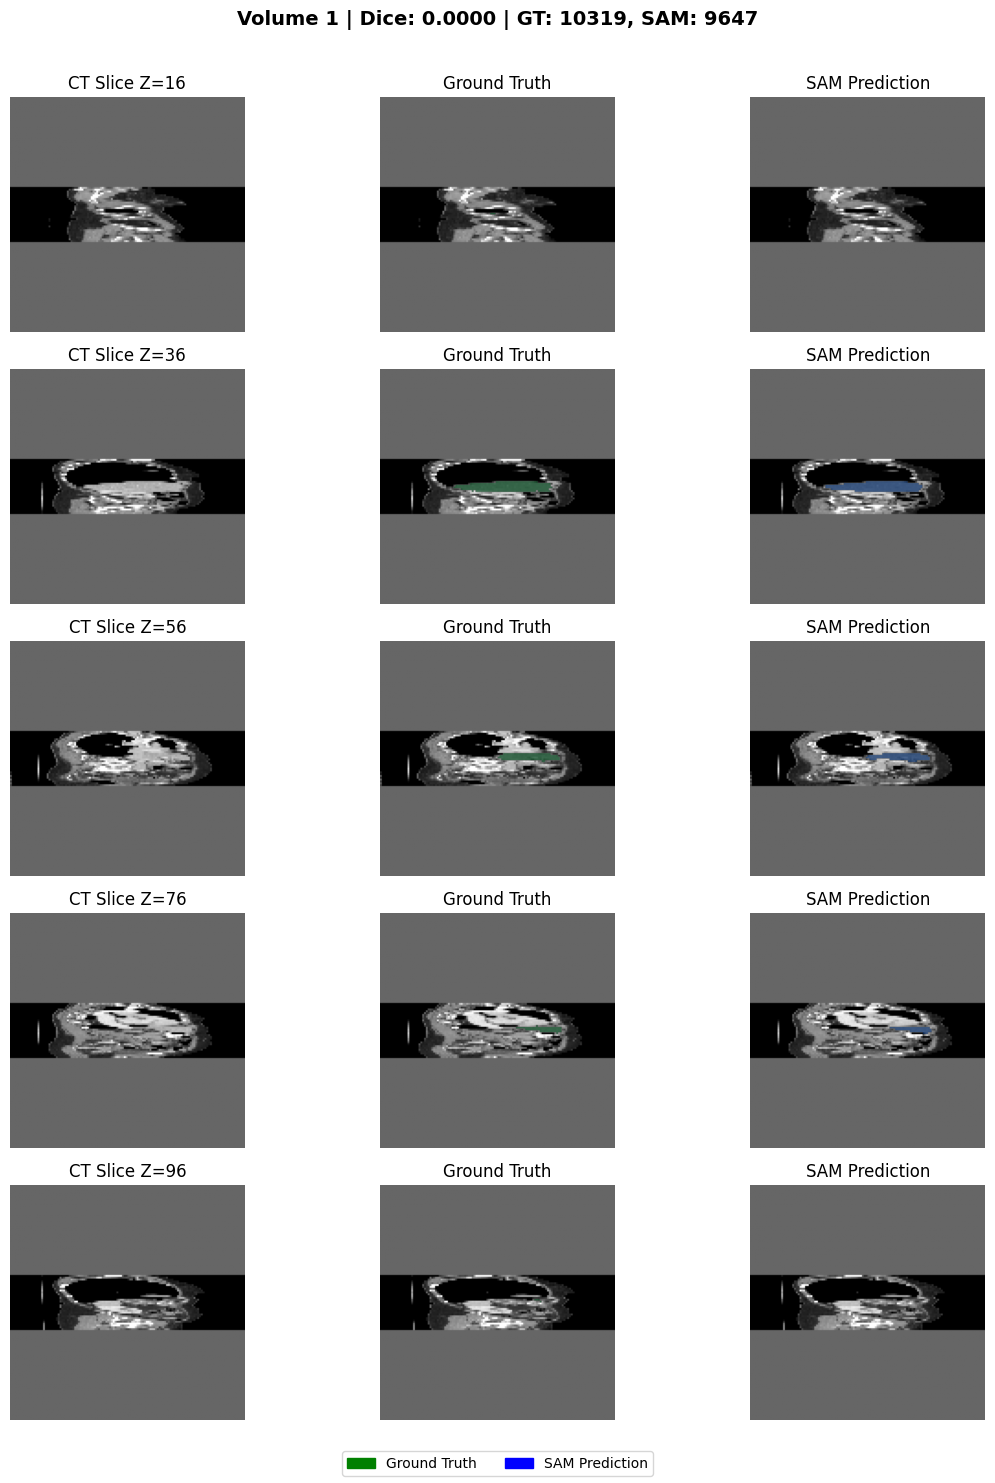

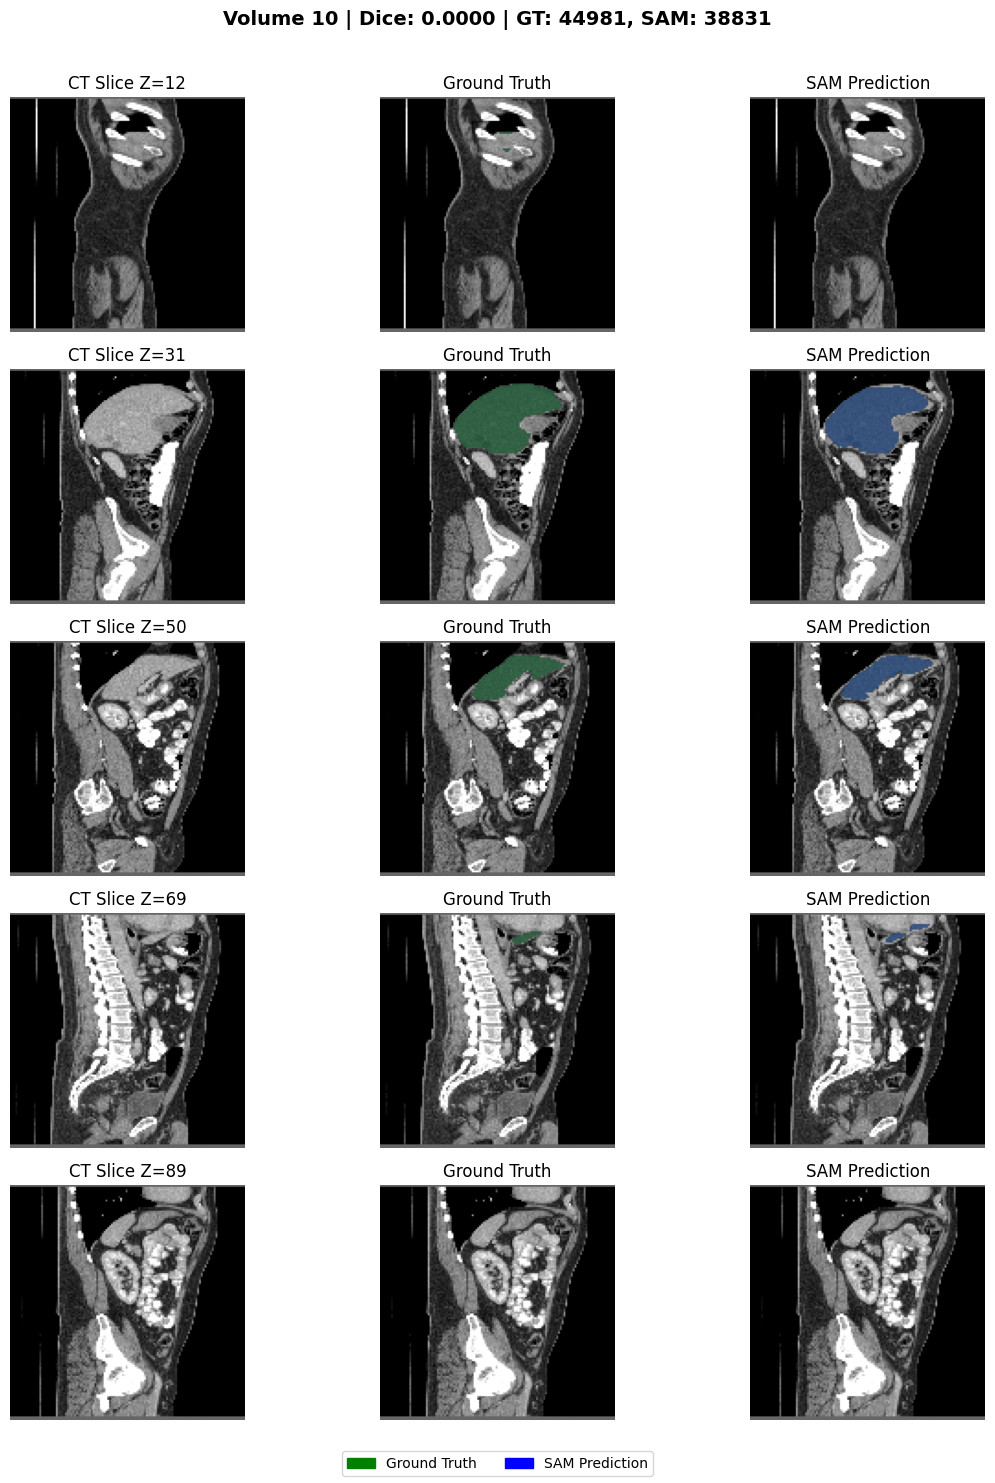

In [12]:
# Visualize first 3 volumes (or change index as needed)
NUM_TO_VISUALIZE = min(3, len([r for r in results if r.get('image_tensor') is not None]))

print(f"Visualizing {NUM_TO_VISUALIZE} volumes...\n")

for result in results[:NUM_TO_VISUALIZE]:
    if result.get('image_tensor') is not None:
        visualize_volume_predictions(result, num_slices=5)

## 9. Save Visualizations to Disk

In [13]:
# Save visualizations for all evaluated volumes
output_dir = project_root / 'results' / 'lits_sam_visualizations'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving visualizations to: {output_dir}\n")

saved_count = 0
for result in results:
    viz_tensor = result.get('viz_tensor')
    if viz_tensor is None:
        viz_tensor = result.get('image_tensor')
    
    if viz_tensor is None:
        if 'error' in result:
            print(f"⚠️ Skipping {result['volume_id']} due to error: {result['error']}")
        continue
    
    volume_id = result['volume_id']
    dice = result.get('dice_score', 0.0)
    gt_mask = result.get('gt_mask')
    pred_mask = result.get('pred_mask')
    
    if gt_mask is None or pred_mask is None:
        continue
    
    coords = np.argwhere(gt_mask > 0)
    if len(coords) == 0:
        print(f"⚠️ Skipping {volume_id}: Empty ground truth")
        continue
    
    z_min, z_max = coords[:, 0].min(), coords[:, 0].max()
    z_indices = np.linspace(z_min, z_max, 5, dtype=int)
    
    fig, axes = plt.subplots(5, 3, figsize=(12, 15))
    
    for idx, z in enumerate(z_indices):
        ct_slice_raw = viz_tensor[0, 0, z].cpu().numpy()
        ct_windowed = apply_ct_window(ct_slice_raw, center=40, width=400)
        ct_slice = orient_axial_slice(ct_windowed)
        gt_slice = orient_axial_slice(gt_mask[z])
        pred_slice = orient_axial_slice(pred_mask[z])
        
        vmin, vmax = ct_slice.min(), ct_slice.max()
        
        axes[idx, 0].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        axes[idx, 0].set_title(f'CT Z={z}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        gt_masked = np.ma.masked_where(gt_slice <= 0, gt_slice)
        axes[idx, 1].imshow(gt_masked, cmap='Greens', alpha=0.7, vmin=0, vmax=1)
        axes[idx, 1].set_title('Ground Truth')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(ct_slice, cmap='gray', vmin=vmin, vmax=vmax)
        pred_masked = np.ma.masked_where(pred_slice <= 0, pred_slice)
        axes[idx, 2].imshow(pred_masked, cmap='Blues', alpha=0.7, vmin=0, vmax=1)
        axes[idx, 2].set_title('SAM Prediction')
        axes[idx, 2].axis('off')
    
    fig.suptitle(
        f'Volume {volume_id} | Dice: {dice:.4f}',
        fontsize=14, fontweight='bold'
    )
    
    legend_elements = [
        mpatches.Patch(color='green', label='Ground Truth'),
        mpatches.Patch(color='blue', label='SAM Prediction'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2)
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    
    output_file = output_dir / f'volume-{volume_id}_sam_comparison.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    saved_count += 1
    print(f"✅ Saved: {output_file.name}")

print(f"\n✅ Visualization complete. Saved {saved_count} images to: {output_dir}")

Saving visualizations to: c:\Users\cahel\Desktop\Med3Tab-PFN\results\lits_sam_visualizations

✅ Saved: volume-0_sam_comparison.png
✅ Saved: volume-1_sam_comparison.png
✅ Saved: volume-10_sam_comparison.png
✅ Saved: volume-11_sam_comparison.png
✅ Saved: volume-12_sam_comparison.png

✅ Visualization complete. Saved 5 images to: c:\Users\cahel\Desktop\Med3Tab-PFN\results\lits_sam_visualizations
